# 3. Does listening warn us, and who comes back?

Questions 5 and 6 of the project ([questions](../docs/questions.md)).

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)  # the daily-logs view reads files by relative path
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

import charts
from analysis import connect, km, survival_at

charts.use_style()
pd.set_option("display.max_columns", 20)
con = connect()

## Q5. Listening before a renewal

Monthly-plan renewal decisions in 2016, with the active days in the ~4 full
weeks before the period ended and in the 4 weeks before that.

The billing-gap rule uses listening, so "people who keep listening don't churn"
could be partly built in. The last column leaves out every renewal that went
through a billing gap, to check.

In [2]:
con.sql("""
    CREATE TEMP TABLE pay AS
    SELECT user_id, subscription_number,
           row_number() OVER w AS payment_number,
           lead(transaction_date) OVER w AS next_payment_date
    FROM core.transactions
    WHERE NOT is_cancel AND amount_paid > 0
    WINDOW w AS (PARTITION BY user_id, subscription_number ORDER BY event_seq)
""")
con.sql("""
    CREATE TEMP TABLE dec AS
    SELECT row_number() OVER () AS id, r.user_id, r.period_end, r.churned, r.is_auto_renew,
           coalesce(NOT r.churned AND p.next_payment_date > r.period_end + 30, false)
               AS renewed_after_billing_gap
    FROM core.renewals AS r
    JOIN pay AS p USING (user_id, subscription_number, payment_number)
    WHERE r.period_end BETWEEN DATE '2016-01-01' AND DATE '2016-12-31' AND r.plan_days <= 31
""")
con.sql("""
    CREATE TEMP TABLE act AS
    SELECT d.id,
        coalesce(sum(w.active_days) FILTER (WHERE w.week >= d.period_end - 34), 0) AS days_last4,
        coalesce(sum(w.active_days) FILTER (WHERE w.week < d.period_end - 34), 0) AS days_prev4
    FROM dec AS d
    LEFT JOIN core.user_weeks AS w
        ON w.user_id = d.user_id AND w.week >= d.period_end - 62 AND w.week + 6 < d.period_end
    GROUP BY d.id
""")
con.sql("""
    CREATE TEMP TABLE da AS
    SELECT d.*, a.days_last4, a.days_prev4,
        CASE WHEN a.days_last4 = 0 THEN '0' WHEN a.days_last4 <= 7 THEN '1-7'
             WHEN a.days_last4 <= 14 THEN '8-14' WHEN a.days_last4 <= 21 THEN '15-21'
             ELSE '22-28' END AS last4,
        CASE WHEN a.days_prev4 = 0 AND a.days_last4 = 0 THEN 'silent both'
             WHEN a.days_prev4 = 0 THEN 'started'
             WHEN a.days_last4 <= 0.5 * a.days_prev4 THEN 'dropped by half+'
             WHEN a.days_last4 >= 1.5 * a.days_prev4 THEN 'up by half+'
             ELSE 'steady' END AS trend
    FROM dec AS d JOIN act AS a USING (id)
""")
cols = """
    count(*) AS decisions,
    round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct_of_decisions,
    round(100 * avg(churned::INT), 2) AS churn_all,
    round(100 * avg(churned::INT) FILTER (WHERE is_auto_renew), 2) AS churn_auto,
    round(100 * avg(churned::INT) FILTER (WHERE NOT is_auto_renew), 2) AS churn_manual,
    round(100 * avg(churned::INT) FILTER (WHERE NOT renewed_after_billing_gap), 2) AS churn_no_billing_gaps,
    round(100.0 * sum(churned::INT) / sum(sum(churned::INT)) OVER (), 1) AS pct_of_churners
"""
by_level = con.sql(f"SELECT last4 AS active_days_last_4_weeks, {cols} FROM da GROUP BY 1 ORDER BY min(days_last4)").df()
display(by_level)
display(con.sql(f"SELECT trend, {cols} FROM da GROUP BY 1 ORDER BY churn_all DESC").df())

,active_days_last_4_weeks,decisions,pct_of_decisions,churn_all,churn_auto,churn_manual,churn_no_billing_gaps,pct_of_churners
0,0,2188909,22.0,4.51,4.23,79.15,4.51,24.4
1,1-7,1647934,16.6,4.63,2.68,41.70,4.67,18.9
2,8-14,1537881,15.5,4.62,1.70,27.65,4.70,17.6
3,15-21,1776841,17.9,4.23,1.33,19.29,4.31,18.6
4,22-28,2796756,28.1,2.97,0.98,10.34,3.02,20.5


,trend,decisions,pct_of_decisions,churn_all,churn_auto,churn_manual,churn_no_billing_gaps,pct_of_churners
0,started,523534,5.3,11.45,2.77,39.04,11.65,14.8
1,up by half+,1204677,12.1,6.48,1.72,26.02,6.58,19.3
2,dropped by half+,837384,8.4,4.64,3.42,36.02,4.68,9.6
3,silent both,1943963,19.5,4.45,4.23,86.04,4.45,21.4
4,steady,5438763,54.7,2.59,1.31,10.61,2.63,34.9


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/03_listening_before_renewal.png')

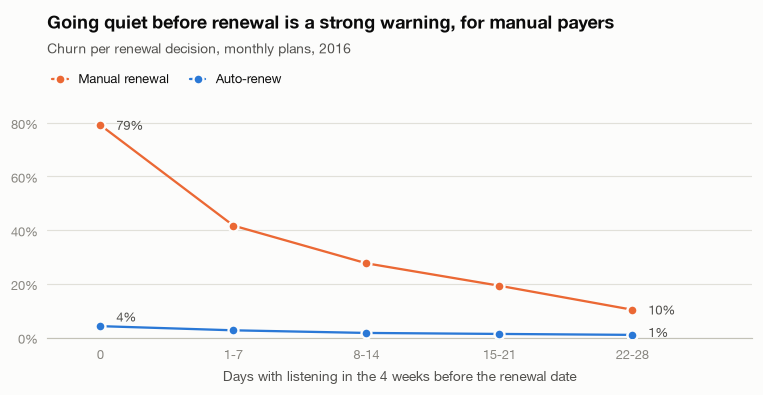

In [3]:
fig, ax = charts.figure(height=3.6)
xs = range(len(by_level))
ax.set_xlim(-0.4, len(by_level) - 0.1)
ax.set_ylim(0, 90)
h_m = charts.line(ax, xs, by_level.churn_manual, charts.ORANGE, "Manual renewal", marker="o", markersize=6.5,
                  markeredgecolor=charts.SURFACE, markeredgewidth=1.5)
h_a = charts.line(ax, xs, by_level.churn_auto, charts.BLUE, "Auto-renew", marker="o", markersize=6.5,
                  markeredgecolor=charts.SURFACE, markeredgewidth=1.5)
charts.note(ax, 0.12, by_level.churn_manual.iloc[0], f"{by_level.churn_manual.iloc[0]:.0f}%")
charts.note(ax, len(by_level) - 1 + 0.12, by_level.churn_manual.iloc[-1], f"{by_level.churn_manual.iloc[-1]:.0f}%")
charts.note(ax, len(by_level) - 1 + 0.12, by_level.churn_auto.iloc[-1] + 1, f"{by_level.churn_auto.iloc[-1]:.0f}%")
charts.note(ax, 0.12, by_level.churn_auto.iloc[0] + 3.5, f"{by_level.churn_auto.iloc[0]:.0f}%")
ax.set_xticks(list(xs))
ax.set_xticklabels(by_level.active_days_last_4_weeks)
ax.set_xlabel("Days with listening in the 4 weeks before the renewal date")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
charts.legend(ax, [(h_m, "Manual renewal"), (h_a, "Auto-renew")])
charts.titles(fig, ax, "Going quiet before renewal is a strong warning, for manual payers",
              "Churn per renewal decision, monthly plans, 2016")
charts.save(fig, "03_listening_before_renewal.png")

### Activation: the first 14 days

New users' first paid subscription (registered from 2015 on, first payment
Jul 2015 – Sep 2016), with the days they listened in the 14 days after their
first payment, read from the daily logs.

In [4]:
con.sql("""
    CREATE TEMP TABLE nu AS
    WITH first_pay AS (
        SELECT user_id, subscription_number, arg_min(is_auto_renew, event_seq) AS first_auto
        FROM core.transactions WHERE NOT is_cancel AND amount_paid > 0 GROUP BY 1, 2
    )
    SELECT s.user_id, s.first_payment_date AS fpd, s.end_date, f.first_auto
    FROM core.subscriptions AS s
    JOIN core.users AS u USING (user_id)
    JOIN first_pay AS f USING (user_id, subscription_number)
    WHERE s.paid_number = 1 AND u.registered_in_window
      AND s.first_payment_date BETWEEN DATE '2015-07-01' AND DATE '2016-09-30'
""")
con.sql("""
    CREATE TEMP TABLE a14 AS
    SELECT n.user_id, count(l.date) AS active_days_14
    FROM nu AS n
    LEFT JOIN staging.user_logs AS l
        ON l.user_id = n.user_id AND l.date >= n.fpd AND l.date < n.fpd + 14
       AND l.total_secs BETWEEN 0 AND 86400
    GROUP BY n.user_id
""")
activation = con.sql("""
    SELECT CASE WHEN a.active_days_14 = 0 THEN '0' WHEN a.active_days_14 <= 3 THEN '1-3'
                WHEN a.active_days_14 <= 7 THEN '4-7' WHEN a.active_days_14 <= 10 THEN '8-10'
                ELSE '11-14' END AS active_days_first_14,
           count(*) AS users,
           round(100 * avg((n.end_date >= n.fpd + 105)::INT), 1) AS still_in_after_3_months,
           round(100 * avg((n.end_date >= n.fpd + 105)::INT) FILTER (WHERE n.first_auto), 1) AS auto_renew,
           round(100 * avg((n.end_date >= n.fpd + 105)::INT) FILTER (WHERE NOT n.first_auto), 1) AS manual
    FROM nu AS n JOIN a14 AS a USING (user_id)
    GROUP BY 1 ORDER BY min(a.active_days_14)
""").df()
display(activation)

,active_days_first_14,users,still_in_after_3_months,auto_renew,manual
0,0,45055,86.3,87.4,36.6
1,1-3,66677,82.5,89.7,35.6
2,4-7,87723,80.7,93.7,49.9
3,8-10,77455,79.5,95.2,58.3
4,11-14,159267,80.4,95.3,69.7


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/03_activation.png')

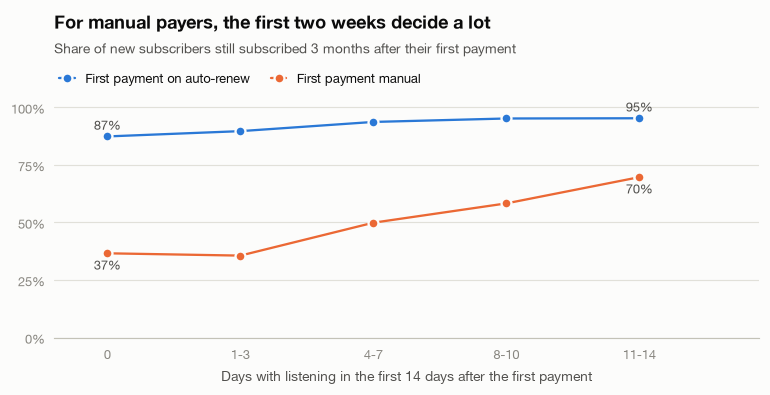

In [5]:
fig, ax = charts.figure(height=3.6)
xs = range(len(activation))
ax.set_xlim(-0.4, len(activation) - 0.1)
ax.set_ylim(0, 105)
h_a = charts.line(ax, xs, activation.auto_renew, charts.BLUE, "Auto-renew", marker="o", markersize=6.5,
                  markeredgecolor=charts.SURFACE, markeredgewidth=1.5)
h_m = charts.line(ax, xs, activation.manual, charts.ORANGE, "Manual", marker="o", markersize=6.5,
                  markeredgecolor=charts.SURFACE, markeredgewidth=1.5)
for series, dy in [(activation.manual, -5), (activation.auto_renew, 5)]:
    charts.note(ax, 0, series.iloc[0] + dy, f"{series.iloc[0]:.0f}%", ha="center")
    charts.note(ax, len(activation) - 1, series.iloc[-1] + dy, f"{series.iloc[-1]:.0f}%", ha="center")
ax.set_xticks(list(xs))
ax.set_xticklabels(activation.active_days_first_14)
ax.set_xlabel("Days with listening in the first 14 days after the first payment")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.yaxis.set_major_locator(mticker.MultipleLocator(25))
charts.legend(ax, [(h_a, "First payment on auto-renew"), (h_m, "First payment manual")])
charts.titles(fig, ax, "For manual payers, the first two weeks decide a lot",
              "Share of new subscribers still subscribed 3 months after their first payment")
charts.save(fig, "03_activation.png")

**What it says.** Listening is a strong warning sign within each payment type,
and strongest for manual payers. Across everyone it looks weak, because most
silent subscribers are on auto-renew and keep paying. Leaving out billing-gap
renewals barely moves the numbers, so the rule isn't creating the pattern.

## Q6. Who comes back, and is it worth it?

Paid subscribers who churned between July 2015 and June 2016, so every one of
them has at least 9 months in which to come back.

In [6]:
con.sql("""
    CREATE TEMP TABLE lost AS
    SELECT s.user_id, s.end_date, s.ended_with_cancel, s.n_payments, s.last_auto_renew,
        (SELECT min(n.first_payment_date) FROM core.subscriptions AS n
          WHERE n.user_id = s.user_id AND n.subscription_number > s.subscription_number AND n.is_paid)
            - s.end_date AS days_to_return
    FROM core.subscriptions AS s
    WHERE s.is_paid AND s.status = 'churned'
      AND s.end_date BETWEEN DATE '2015-07-01' AND DATE '2016-06-30'
""")
back = lambda d: f"round(100 * avg(coalesce(days_to_return <= {d}, false)::INT), 1)"
display(con.sql(f"""
    SELECT count(*) AS churned, {back(90)} AS back_in_90_days, {back(180)} AS back_in_180_days,
           {back(270)} AS back_in_270_days, median(days_to_return) AS median_days_if_back
    FROM lost
""").df())
ended = con.sql(f"""
    SELECT CASE WHEN ended_with_cancel THEN 'Cancelled'
                WHEN last_auto_renew THEN 'Auto-renew payment stopped'
                ELSE 'Manual, didn''t renew' END AS how_it_ended,
           count(*) AS churned, {back(180)} AS back_in_180_days
    FROM lost GROUP BY 1 ORDER BY back_in_180_days DESC
""").df()
display(ended)
display(con.sql(f"""
    SELECT CASE WHEN n_payments = 1 THEN '1 payment' WHEN n_payments <= 3 THEN '2-3'
                WHEN n_payments <= 12 THEN '4-12' ELSE '13+' END AS tenure,
           count(*) AS churned, {back(180)} AS back_in_180_days
    FROM lost GROUP BY 1 ORDER BY min(n_payments)
""").df())

,churned,back_in_90_days,back_in_180_days,back_in_270_days,median_days_if_back
0,440923,20.4,31.2,34.6,83.0


,how_it_ended,churned,back_in_180_days
0,Auto-renew payment stopped,37135,87.7
1,"Manual, didn't renew",237689,37.5
2,Cancelled,166099,9.7


,tenure,churned,back_in_180_days
0,1 payment,154748,31.9
1,2-3,84667,36.1
2,4-12,155727,33.0
3,13+,45781,13.6


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/03_winback.png')

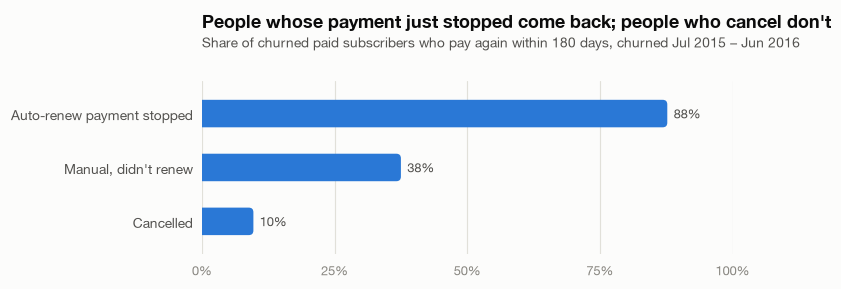

In [7]:
fig, ax = charts.figure(height=2.8, left=0.3, bottom=0.12, top=0.68)
ys = [2, 1, 0]
ax.set_ylim(-0.6, 2.6)
ax.set_xlim(0, 100)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.spines["bottom"].set_visible(False)
charts.bars(ax, ys, ended.back_in_180_days.values, charts.BLUE, horizontal=True)
for y, v in zip(ys, ended.back_in_180_days.values):
    charts.note(ax, v + 1.2, y, f"{v:.0f}%")
ax.set_yticks(ys)
ax.set_yticklabels(ended.how_it_ended, color=charts.INK_2, fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.xaxis.set_major_locator(mticker.MultipleLocator(25))
charts.titles(fig, ax, "People whose payment just stopped come back; people who cancel don't",
              "Share of churned paid subscribers who pay again within 180 days, churned Jul 2015 – Jun 2016")
charts.save(fig, "03_winback.png")

### Are returning subscribers worth as much?

In [8]:
display(con.sql("""
    WITH subs AS (
        SELECT s.user_id, s.subscription_number, s.first_payment_date AS fpd,
               CASE WHEN s.paid_number > 1 THEN 'returning' ELSE 'new' END AS kind
        FROM core.subscriptions AS s
        JOIN core.users AS u USING (user_id)
        WHERE s.is_paid AND s.first_payment_date BETWEEN DATE '2015-07-01' AND DATE '2015-12-31'
          AND (s.paid_number > 1 OR u.registered_in_window)
    )
    SELECT kind, count(DISTINCT (user_id, subscription_number)) AS subscriptions,
           round(sum(t.amount_paid) / count(DISTINCT (user_id, subscription_number))) AS revenue_first_12_months_ntd
    FROM subs JOIN core.transactions AS t USING (user_id, subscription_number)
    WHERE NOT t.is_cancel AND t.transaction_date < subs.fpd + 365
    GROUP BY 1
""").df())

returning = con.sql("""
    SELECT CASE WHEN s.paid_number > 1 THEN 'returning' ELSE 'new' END AS kind,
           least(s.end_date, DATE '2017-03-31') - s.first_payment_date AS days,
           (s.status = 'churned')::INT AS churned
    FROM core.subscriptions AS s
    JOIN core.users AS u USING (user_id)
    WHERE s.is_paid AND s.first_payment_date BETWEEN DATE '2015-07-01' AND DATE '2016-06-30'
      AND s.end_date >= s.first_payment_date AND (s.paid_number > 1 OR u.registered_in_window)
""").df()
display(pd.DataFrame({
    kind: [len(g)] + [round(100 * survival_at(km(g.days.values, g.churned.values), 30 * m + 15), 1)
                      for m in [1, 3, 6, 12]]
    for kind, g in returning.groupby("kind")
}, index=["subscriptions", "month 1", "month 3", "month 6", "month 12"]).T)

,kind,subscriptions,revenue_first_12_months_ntd
0,returning,55228,817.0
1,new,182951,1134.0


,subscriptions,month 1,month 3,month 6,month 12
new,355362.0,88.6,81.1,75.3,66.3
returning,131777.0,69.2,54.4,42.7,34.1


**What it says.** About a third of churned subscribers pay again within six
months, mostly people whose auto-renew payment simply stopped: they come back
on their own. People who cancelled rarely return. Returning subscribers bring
in less in their first year and churn faster, so a win-back campaign should aim
at manual lapsers, and a payment-failure flow should aim at shortening the gap.